In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'instacart-market-basket-analysis' dataset.
Path to dataset files: /kaggle/input/instacart-market-basket-analysis


### 1. Import Libraries

In [17]:
import pandas as pd

### 2. Load Dataset (Sample use for speed)

In [18]:
orders = pd.read_csv(f'{path}/orders.csv', nrows=10000)
order_products = pd.read_csv(f'{path}/order_products__prior.csv', nrows=10000)
products = pd.read_csv(f'{path}/products.csv')

### 3. Merge Datasets

In [19]:
data = pd.merge(order_products, products, on="product_id")
data = pd.merge(data, orders, on="order_id")

### 4. Check Missing Values

In [20]:
print(data.isnull().sum())

order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
product_name              0
aisle_id                  0
department_id             0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


### 5. Handle Missing Values

In [21]:
data = data.dropna()

### 6. Remove Duplicates

In [22]:
data = data.drop_duplicates()

### 7. Select Important Columns

In [23]:
data = data[['order_id', 'user_id', 'product_name', 'add_to_cart_order', 'reordered']]

### 8. Create Basket (Transaction Format)

In [24]:
basket = data.groupby(['order_id', 'product_name'])['add_to_cart_order'] \
             .count().unstack().fillna(0)

### 9. Convert into Binary (0/1)

In [25]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

/tmp/ipykernel_13104/3498954818.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


### 10. Final Dataset Check

In [26]:
print(basket.head())
print("Shape:", basket.shape)

product_name  Banana  Berry Medley  Boneless Skinless Chicken Breasts  \
order_id                                                                
40                 0             0                                  0   
214                1             1                                  1   

product_name  Broccoli Crown  Chocolate Milk 1% Milkfat  Colby Jack Cheese  \
order_id                                                                     
40                         0                          1                  0   
214                        1                          0                  1   

product_name  Instant Oatmeal Variety Pack  Just Mayo  Macaroni & Cheese  \
order_id                                                                   
40                                       0          0                  1   
214                                      1          1                  0   

product_name  Organic 1% Low Fat Milk  \
order_id                                
40     

### 11. Data Visualization: Top Products

/tmp/ipykernel_13104/1775653154.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_products.index, y=top_10_products.values, palette='viridis')


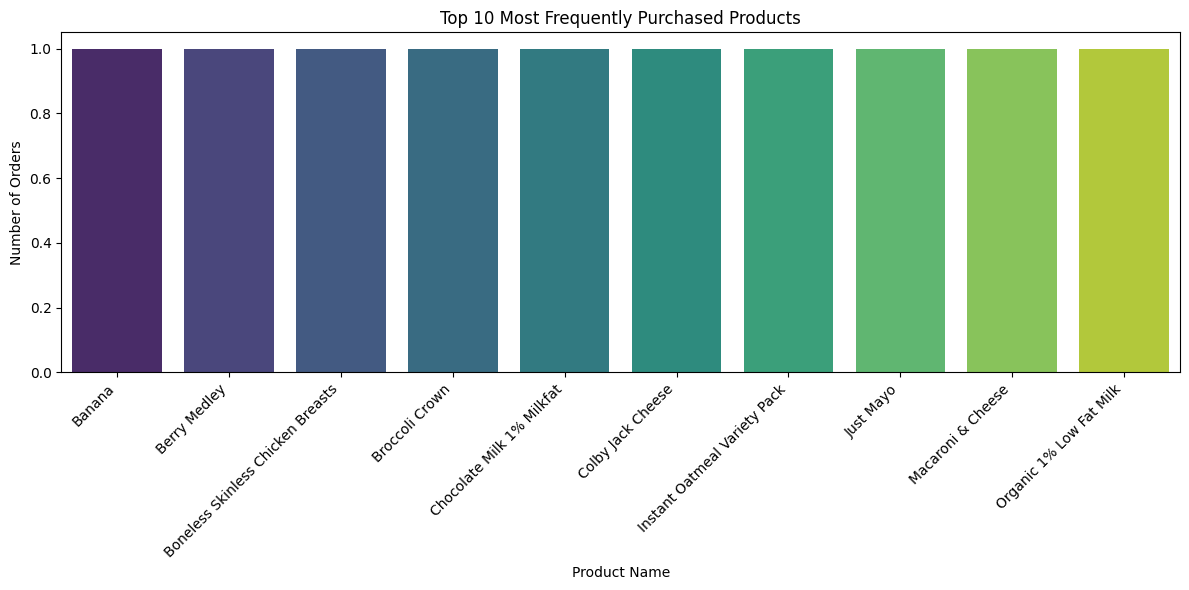

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the frequency of each product across all baskets
product_frequency = basket.sum().sort_values(ascending=False)

# Get the top 10 most frequent products
top_10_products = product_frequency.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_products.index, y=top_10_products.values, palette='viridis')
plt.title('Top 10 Most Frequently Purchased Products')
plt.xlabel('Product Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 12. Data Visualization: Distribution of Items in Cart

/tmp/ipykernel_13104/2903759605.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data['add_to_cart_order'], bins=30, kde=True, palette='coolwarm')


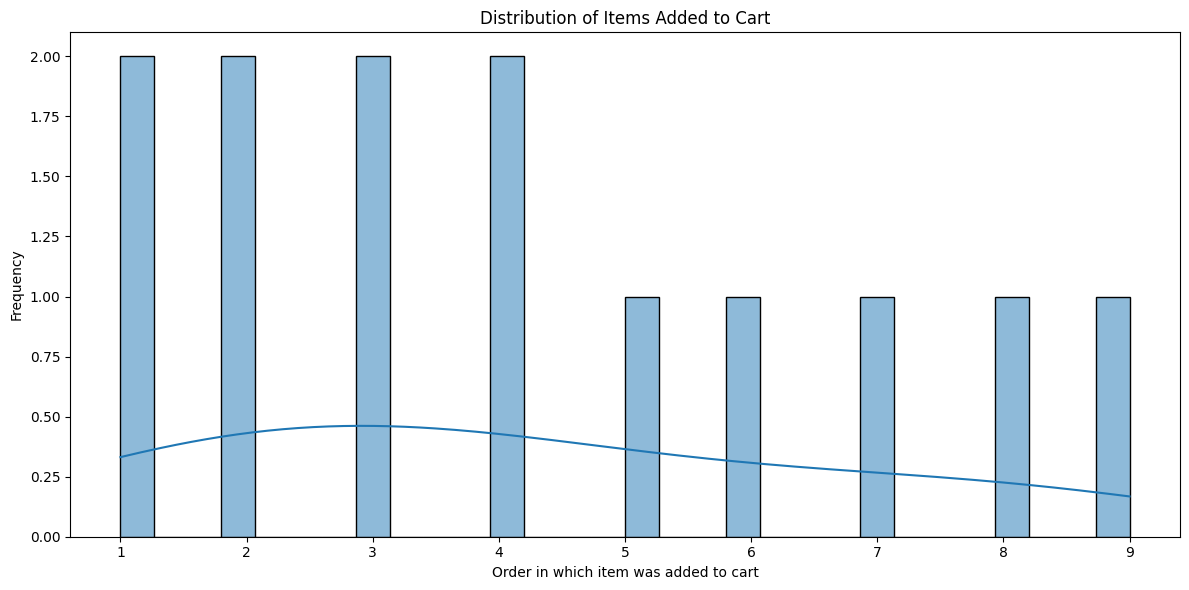

In [28]:
plt.figure(figsize=(12, 6))
sns.histplot(data['add_to_cart_order'], bins=30, kde=True, palette='coolwarm')
plt.title('Distribution of Items Added to Cart')
plt.xlabel('Order in which item was added to cart')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 13. Data Visualization: Order Frequency by Day of Week and Hour of Day

### 14. Calculate Average Number of Items per Order

In [30]:
average_items_per_order = data.groupby('order_id')['product_name'].count().mean()
print(f"Average number of items per order: {average_items_per_order:.2f}")

Average number of items per order: 6.50


### 15. Data Visualization: Average Items per Order

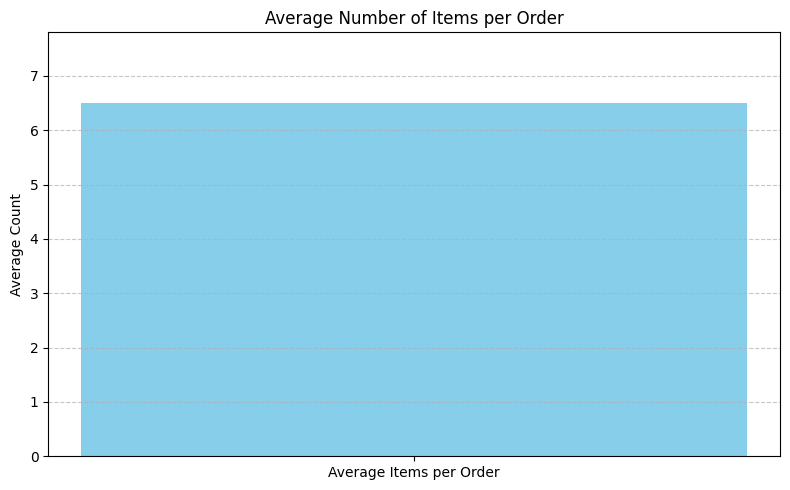

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(['Average Items per Order'], [average_items_per_order], color='skyblue')
plt.title('Average Number of Items per Order')
plt.ylabel('Average Count')
plt.ylim(0, average_items_per_order * 1.2) # Set y-limit slightly above the value for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 16. Market Basket Analysis: Apriori Algorithm

In [33]:
# Install mlxtend if not already installed
# !pip install mlxtend

In [34]:
from mlxtend.frequent_patterns import apriori, association_rules

# Apply the Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)

print("Frequent Itemsets:")
display(frequent_itemsets.head())

Frequent Itemsets:


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
0,0.5,(Banana)
1,0.5,(Berry Medley)
2,0.5,(Boneless Skinless Chicken Breasts)
3,0.5,(Broccoli Crown)
4,0.5,(Chocolate Milk 1% Milkfat)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [36]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print("Association Rules:")
display(rules.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Association Rules:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Banana),(Berry Medley),0.5,0.5,0.5,1.0,2.0,1.0,0.25,inf,1.0,1.0,1.0,1.0
1,(Berry Medley),(Banana),0.5,0.5,0.5,1.0,2.0,1.0,0.25,inf,1.0,1.0,1.0,1.0
2,(Banana),(Boneless Skinless Chicken Breasts),0.5,0.5,0.5,1.0,2.0,1.0,0.25,inf,1.0,1.0,1.0,1.0
3,(Boneless Skinless Chicken Breasts),(Banana),0.5,0.5,0.5,1.0,2.0,1.0,0.25,inf,1.0,1.0,1.0,1.0
4,(Banana),(Broccoli Crown),0.5,0.5,0.5,1.0,2.0,1.0,0.25,inf,1.0,1.0,1.0,1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Explanation of Apriori Results:

*   **Frequent Itemsets**: These are collections of items that frequently appear together in orders. `support` indicates how frequently an itemset appears.
*   **Association Rules**: These rules tell us that if a customer buys item A (antecedent), they are also likely to buy item B (consequent).
    *   **Support**: The proportion of transactions that contain both the antecedent and consequent.
    *   **Confidence**: The probability that a customer will buy the consequent, given that they have already bought the antecedent.
    *   **Lift**: Indicates how much more likely the consequent is to be bought when the antecedent is bought, compared to its baseline probability. A lift value greater than 1 suggests a positive correlation.

### 17. Apply K-Means Clustering

In [39]:
from sklearn.cluster import KMeans

# Initialize KMeans with 2 clusters (maximum possible given the number of samples)
# Set random_state for reproducibility
k_means_model = KMeans(n_clusters=2, random_state=42, n_init=10) # n_init is set to suppress warning

# Fit the model and predict clusters
basket['cluster'] = k_means_model.fit_predict(basket.drop('cluster', axis=1, errors='ignore'))

print("Basket with cluster labels:")
display(basket.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Basket with cluster labels:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


product_name,Banana,Berry Medley,Boneless Skinless Chicken Breasts,Broccoli Crown,Chocolate Milk 1% Milkfat,Colby Jack Cheese,Instant Oatmeal Variety Pack,Just Mayo,Macaroni & Cheese,Organic 1% Low Fat Milk,Organic Cream Of Chicken Condensed Soup,Organic Hearty Split Pea & Uncured Ham Soup,Sparkling Natural Mineral Water,cluster
order_id,,,,,,,,,,,,,,
40,0,0,0,0,1,0,0,0,1,1,0,0,1,0
214,1,1,1,1,0,1,1,1,0,0,1,1,0,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 18. Analyze Cluster Characteristics

Now let's examine the characteristics of each cluster by looking at the average presence of each product within that cluster. This will help us understand what makes each cluster distinct.

In [40]:
cluster_product_means = basket.groupby('cluster').mean()

print("Average product presence per cluster:")
display(cluster_product_means.head())

# You can also look at the top products for each cluster
for i in range(k_means_model.n_clusters):
    print(f"\nTop products in Cluster {i}:")
    display(cluster_product_means.loc[i].sort_values(ascending=False).head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Average product presence per cluster:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

product_name,Banana,Berry Medley,Boneless Skinless Chicken Breasts,Broccoli Crown,Chocolate Milk 1% Milkfat,Colby Jack Cheese,Instant Oatmeal Variety Pack,Just Mayo,Macaroni & Cheese,Organic 1% Low Fat Milk,Organic Cream Of Chicken Condensed Soup,Organic Hearty Split Pea & Uncured Ham Soup,Sparkling Natural Mineral Water
cluster,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0



Top products in Cluster 0:


...

,0
product_name,
Chocolate Milk 1% Milkfat,1.0
Organic 1% Low Fat Milk,1.0
Sparkling Natural Mineral Water,1.0
Macaroni & Cheese,1.0
Banana,0.0



Top products in Cluster 1:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,1
product_name,
Banana,1.0
Berry Medley,1.0
Boneless Skinless Chicken Breasts,1.0
Broccoli Crown,1.0
Colby Jack Cheese,1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Explanation of K-Means Clustering Results:

*   **K-Means Algorithm**: K-Means is an unsupervised learning algorithm used to partition `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid).
*   **`basket['cluster']`**: A new column has been added to your `basket` DataFrame, indicating which cluster each order belongs to.
*   **`cluster_product_means`**: This DataFrame shows the average presence (0 or 1) of each product within each cluster. A higher mean value indicates that the product is more frequently purchased by customers in that specific cluster. This helps in understanding the typical "basket" for each customer segment.

To find the optimal number of clusters (K), you can use methods like the **Elbow Method** or **Silhouette Score**. Would you like me to demonstrate the Elbow Method to help determine a more appropriate `n_clusters` value?

### Explanation of Agglomerative Hierarchical Clustering

**Agglomerative Hierarchical Clustering** is a 'bottom-up' approach to clustering. It starts with each data point as its own cluster and then progressively merges pairs of clusters until all data points belong to a single cluster or a stopping criterion is met.

**How it works:**
1.  **Initialization:** Each data point (in our case, each customer order represented in the `basket` DataFrame) is considered a single cluster.
2.  **Distance Calculation:** The algorithm calculates the 'distance' or dissimilarity between all pairs of clusters. Common distance metrics for binary data like ours include Jaccard distance or Hamming distance.
3.  **Merging:** The two closest clusters are merged into a new, larger cluster.
4.  **Iteration:** Steps 2 and 3 are repeated until only one large cluster remains, or a predefined number of clusters is reached.

**Key Concepts:**
*   **Dendrogram:** The merging process can be visualized as a tree-like diagram called a dendrogram. By cutting the dendrogram at a certain height, you can determine the number of clusters.
*   **Linkage Criteria:** This determines how the distance between two clusters is calculated (e.g., single linkage - shortest distance between points in clusters, complete linkage - longest distance, average linkage - average distance, Ward's method - minimizes variance within clusters).

**Advantages:**
*   Does not require specifying the number of clusters (K) beforehand, as the dendrogram allows for visual determination.
*   Produces a hierarchy of clusters, which can be useful for understanding relationships at different levels of granularity.

**Disadvantages:**
*   Can be computationally expensive for large datasets (O(n^3) complexity).
*   Once a merge is made, it cannot be undone, which can sometimes lead to suboptimal clusters if early merges were poor.

**Application in Instacart:**
Agglomerative clustering could help us identify a hierarchy of customer buying behaviors. For instance, we might find a broad cluster of 'healthy shoppers' which then branches into sub-clusters like 'organic produce buyers' and 'meat and dairy buyers'. This could be valuable for targeted marketing campaigns or store layout optimization.

### 19. Apply DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

In [46]:
from sklearn.cluster import DBSCAN

# Drop the 'cluster' column if it exists from previous clustering attempts
basket_dbscan = basket.drop('cluster', axis=1, errors='ignore')

# Initialize DBSCAN. Given the very small sample size (2 orders), typical parameters
# might not yield meaningful clusters. We'll set min_samples to 1 to allow for discovery
# of individual clusters if they are sufficiently dense or as noise.
# The 'eps' parameter is crucial and depends on the distance metric. For binary data,
# Hamming distance or Jaccard distance could be more appropriate than Euclidean. For simplicity,
# using default Euclidean distance for now with a small 'eps' value.
dbscan_model = DBSCAN(eps=0.5, min_samples=1) # Adjust eps and min_samples as needed

# Fit the model and predict clusters
basket['dbscan_cluster'] = dbscan_model.fit_predict(basket_dbscan)

print("Basket with DBSCAN cluster labels:")
display(basket.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Basket with DBSCAN cluster labels:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

product_name,Banana,Berry Medley,Boneless Skinless Chicken Breasts,Broccoli Crown,Chocolate Milk 1% Milkfat,Colby Jack Cheese,Instant Oatmeal Variety Pack,Just Mayo,Macaroni & Cheese,Organic 1% Low Fat Milk,Organic Cream Of Chicken Condensed Soup,Organic Hearty Split Pea & Uncured Ham Soup,Sparkling Natural Mineral Water,cluster,dbscan_cluster
order_id,,,,,,,,,,,,,,,
40,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0
214,1,1,1,1,0,1,1,1,0,0,1,1,0,1,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [47]:
print("Basket DataFrame with DBSCAN cluster assignments:")
display(basket[['dbscan_cluster']].head(3))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Basket DataFrame with DBSCAN cluster assignments:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

product_name,dbscan_cluster
order_id,
40,0
214,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 20. Data Visualization: DBSCAN Cluster Distribution

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

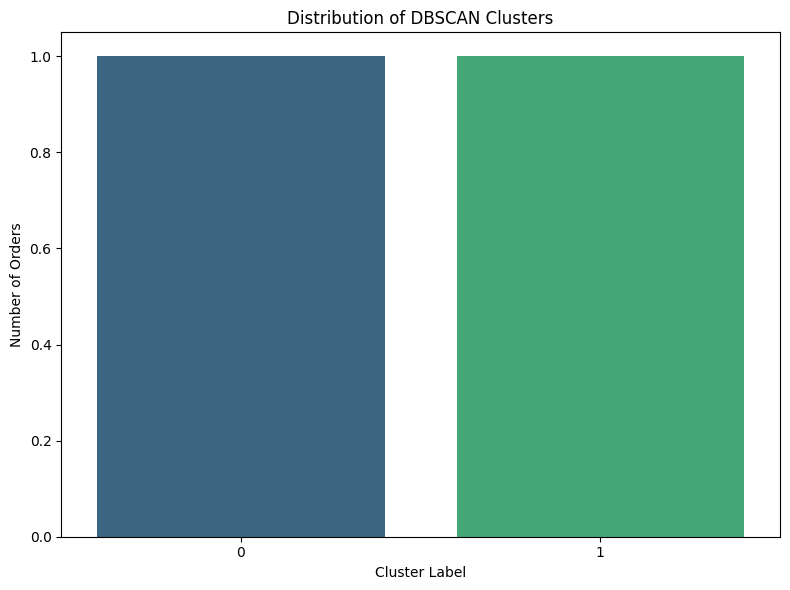

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [48]:
plt.figure(figsize=(8, 6))
sns.countplot(x='dbscan_cluster', data=basket, palette='viridis')
plt.title('Distribution of DBSCAN Clusters')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()